In [3]:
import torch
from models.image_encoder_no_cond import ImageEncoder
from models.image_decoder import ImageDecoder
from models.pcd_encoder import PCDEncoder
from models.pcd_decoder_edges import PCDDecoder
from preprocessing_src.dataloader import MultiModalBatch, make_loader, collate_pt_dicts, PtDictFolderDataset
from torch_geometric.data import Data
import torch_geometric.nn.functional as F_geom
from torch_geometric.nn import SimpleConv, MLP, Linear
from torch_geometric.nn import pool
from torch.nn import ModuleList
import torch.nn as nn
import math
import pandas as pd
from typing import Optional, Tuple, Dict
import torch.nn.functional as F

device = torch.device('cpu')
torch.set_default_dtype(torch.float32)

## Dataset
loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/combined_dataset', batch_size=1, shuffle=True, num_workers=4)
#loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/single_sample', batch_size=1, shuffle=True, num_workers=4)

In [4]:
## Model Definition

class ImageGraphAE(nn.Module):
    def __init__(self,latent_dim,use_z_norm=True,use_ss=True):
        super().__init__()
        self.latent_dim = latent_dim
        self.use_ss = use_ss
        self.use_z_norm = use_z_norm
        basedim = 32
        self.img_enc = ImageEncoder(latent_dim=latent_dim, base_dim=basedim, token_dim=256)
        self.img_dec = ImageDecoder(latent_dim=latent_dim, base_dim=basedim, out_hw=(384,512), norm='group', groups=16, out_act='sigmoid')
        self.pcd_enc = PCDEncoder(latent_dim=64,layers=8,layers_mlp=2,z_dim=latent_dim)
        self.pcd_dec = PCDDecoder(nodes_dim=6,latent_dim=latent_dim,nodes_init=12000,nodes_k=3,layers=8)

        self.pcd_proj = MLP(in_channels=6,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='relu',norm='layer')

        # visibility projection: [area, volume]
        self.vis_proj = MLP(in_channels=10,hidden_channels=32,out_channels=latent_dim,num_layers=4,act='relu',norm='layer')
        
        self.vis_head = nn.Linear(latent_dim,2)
        return

    def cond(self, z, vis=None):
        if self.use_z_norm == True:
            z = F.layer_norm(z, (z.shape[-1],))
            vis = vis.squeeze(1)
            z = z + self.vis_proj(vis)
        return z

    def forward(self,img, pcd, batch, edge_index, edge_weights, vis=None):
        z_img = self.img_enc(img)
        z_pcd = self.pcd_enc(pcd,batch,edge_index,edge_weights)

        #print(vis.shape,self.vis_proj(vis).shape)
        if self.use_ss == True:
            z_img = self.cond(z_img,vis)
            z_pcd = self.cond(z_pcd,vis)

        ## image-->image, pcd-->pcd reconstruction
        img_img = self.img_dec(z_img)
        pcd_pcd = self.pcd_dec(z_pcd)

        ## image-->pcd, pcd-->image reconstruction
        img_pcd = self.pcd_dec(z_img)
        pcd_img = self.img_dec(z_pcd)

        out = dict(z_img=z_img,z_pcd=z_pcd,img_img=img_img,img_pcd=img_pcd,pcd_pcd=pcd_pcd,pcd_img=pcd_img)

        return out


In [ ]:
## Reconstruction model -> from partial data

In [93]:
rw = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks/rw_1_39.pt',weights_only=False)
print(rw)

{'img': tensor([[[0.4039, 0.4000, 0.4235],
         [0.3490, 0.3137, 0.3176],
         [0.4118, 0.4078, 0.4275],
         ...,
         [0.2353, 0.1961, 0.2235],
         [0.2431, 0.2000, 0.2275],
         [0.0000, 0.0000, 0.0000]],

        [[0.4078, 0.3882, 0.4157],
         [0.4078, 0.3882, 0.4157],
         [0.4157, 0.3961, 0.4235],
         ...,
         [0.2588, 0.2039, 0.2118],
         [0.2392, 0.2000, 0.2314],
         [0.0000, 0.0000, 0.0000]],

        [[0.3765, 0.3412, 0.3569],
         [0.4039, 0.3922, 0.4196],
         [0.3608, 0.3216, 0.3333],
         ...,
         [0.2745, 0.2588, 0.2745],
         [0.2863, 0.2706, 0.2824],
         [0.0000, 0.0000, 0.0000]],

        ...,

        [[0.0000, 0.0000, 0.0000],
         [0.5255, 0.4784, 0.3922],
         [0.0000, 0.0000, 0.0000],
         ...,
         [0.4157, 0.3412, 0.2784],
         [0.4235, 0.3490, 0.2941],
         [0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000],
         [0.5137, 0.4706, 0.3922],
    

In [5]:
## Generate Results - Image Only - from Random Walk
loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks', batch_size=1, shuffle=False, num_workers=4)

alias = '0210_novis'
model_weights = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/model/{alias}/model_weights_19800.pt'
state = torch.load(model_weights, map_location=device)
model = ImageGraphAE(latent_dim=128,use_z_norm=False,use_ss=False).to(device)
model.load_state_dict(state)
model.eval()

z_dict = {}
i = 0
j = 1
for batch in loader:
    batch = batch.to(device)
    
    img_in = batch['img'].permute(0,3,1,2).to(torch.float32)
    #print(img_in.shape,img_in.dtype)
    #R,t -> None
    pcd_in = batch['pcd'].to(torch.float32)
    pcd_in[:,:3] = -pcd_in[:,:3]
    edge_index = batch['edge_index']
    edge_weights = batch['edge_weights'].to(torch.float32)
    vis_in = torch.zeros(5,2)
    if i == 40:
        j = 2
    i+=1
    with torch.no_grad():
        pred = model(img_in,pcd_in,batch.batch,edge_index,edge_weights,vis_in)
        z_dict[f'rw_{j}_{i%40}'] = pred['z_img']

if False:
    img_in = img_in.permute(0,2,3,1).squeeze(0).float()[..., [2,1,0]]
    img_img = ((pred['img_img'].permute(0,2,3,1).squeeze(0))).clamp(0,1)[..., [2,1,0]]
    pcd_img = ((pred['pcd_img'].permute(0,2,3,1).squeeze(0))).clamp(0,1)[..., [2,1,0]]
    pcd_pcd = pred['pcd_pcd'].x
    pcd_pcd[:,3:] = ((pcd_pcd[:,3:]+1)/2).clamp(0,1)
    img_pcd = pred['img_pcd'].x
    img_pcd[:,3:] = ((img_pcd[:,3:]+1)/2).clamp(0,1)
    print(F.mse_loss(pred['z_img'],pred['z_pcd']).item())

In [ ]:
## Generate Results - with point cloud
alias = '0210_novis'
model_weights = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/model/{alias}/model_weights_19800.pt'
state = torch.load(model_weights, map_location=device)
model = ImageGraphAE(latent_dim=128,use_z_norm=False,use_ss=True).to(device)
model.load_state_dict(state)
model.eval()

for batch in loader:
    batch = batch.to(device)
    
    img_in = batch['img'].permute(0,3,1,2).to(torch.float32)
    #print(img_in.shape,img_in.dtype)
    #R,t -> None
    pcd_in = batch['pcd'].to(torch.float32)
    pcd_in[:,:3] = -pcd_in[:,:3]
    edge_index = batch['edge_index']
    edge_weights = batch['edge_weights'].to(torch.float32)
    vis_in = batch['vis']

# 2D: area, mean distance, max distance, min distance, area stdev
# 3D: volume, mean depth, max depth, min depth, volume stdev
#pcd_in[:,1] = pcd_in[:,1]*2

with torch.no_grad():
    pred = model(img_in,pcd_in,batch.batch,edge_index,edge_weights,vis_in)

img_in = img_in.permute(0,2,3,1).squeeze(0).float()[..., [2,1,0]]
img_img = ((pred['img_img'].permute(0,2,3,1).squeeze(0))).clamp(0,1)[..., [2,1,0]]
pcd_img = ((pred['pcd_img'].permute(0,2,3,1).squeeze(0))).clamp(0,1)[..., [2,1,0]]
pcd_pcd = pred['pcd_pcd'].x
pcd_pcd[:,3:] = ((pcd_pcd[:,3:]+1)/2).clamp(0,1)
img_pcd = pred['img_pcd'].x
img_pcd[:,3:] = ((img_pcd[:,3:]+1)/2).clamp(0,1)
print(F.mse_loss(pred['z_img'],pred['z_pcd']).item())

AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/cluster/home/btuncay/gnn_312/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
           ^^^^^^^^^^^^^^^^^^^^
  File "/cluster/home/btuncay/gnn_312/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/cluster/home/btuncay/cog/gnn_spatial_reasoning/preprocessing_src/dataloader.py", line 58, in __getitem__
    if sample["pcd"].dim() != 2:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'numpy.ndarray' object has no attribute 'dim'. Did you mean: 'ndim'?


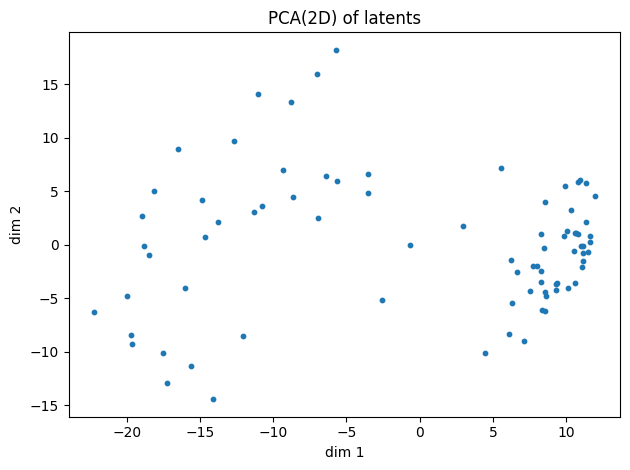

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def dict_to_matrix(latent_dict, get_z=lambda v: v, get_label=lambda k, v: None):
    keys = list(latent_dict.keys())
    Z = np.stack([np.asarray(get_z(latent_dict[k])).reshape(-1) for k in keys], axis=0)
    labels = [get_label(k, latent_dict[k]) for k in keys]
    return keys, Z, np.array(labels, dtype=object)

def plot_2d(X2, labels=None, title="latent viz"):
    plt.figure()
    if labels is None or np.all(labels == None):
        plt.scatter(X2[:,0], X2[:,1], s=10)
    else:
        uniq = [u for u in np.unique(labels) if u is not None]
        for u in uniq:
            m = labels == u
            plt.scatter(X2[m,0], X2[m,1], s=10, label=str(u))
            plt.text(X2[m,0], X2[m,1] - 0.2, str(u), fontsize=20)
        plt.legend(markerscale=2)
    plt.title(title)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.tight_layout()
    plt.show()

# --- PCA (fast baseline) ---
def pca_2d(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    return Zc @ Vt[:2].T

keys, Z, labels = dict_to_matrix(z_dict)
X2 = pca_2d(Z)
plot_2d(X2, labels, title="PCA(2D) of latents")

/cluster/home/btuncay/gnn_312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


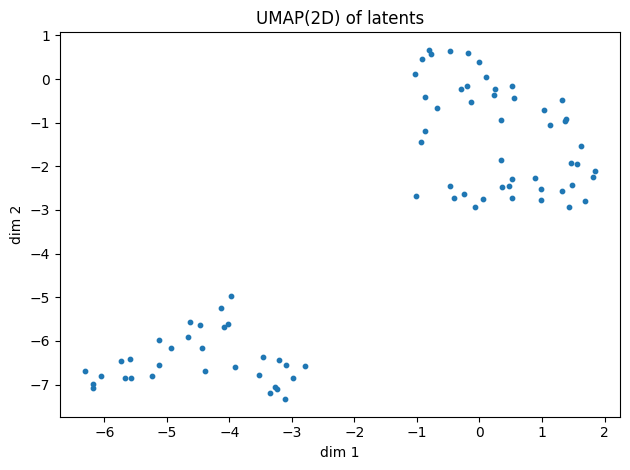

In [19]:
import umap

X2_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0).fit_transform(Z)
plot_2d(X2_umap, labels, title="UMAP(2D) of latents")

# Fixes

Image channels from *img_in* $\rightarrow$ rearrange [2,1,0]

Point cloud extractor:
- z dimension flipped
- insufficient / incorrect points

Check encoders

Transform point cloud to always face the same direction

PCD decoder $\Rightarrow$ invariant to graph dimensions!

PCD pipeline $\Rightarrow$ equivariant

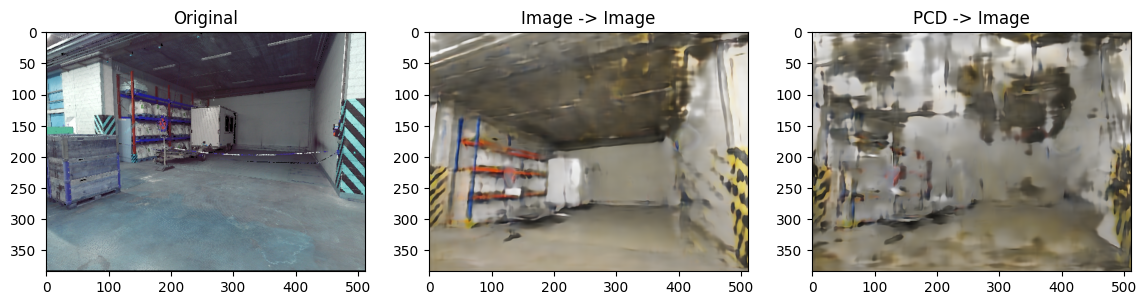

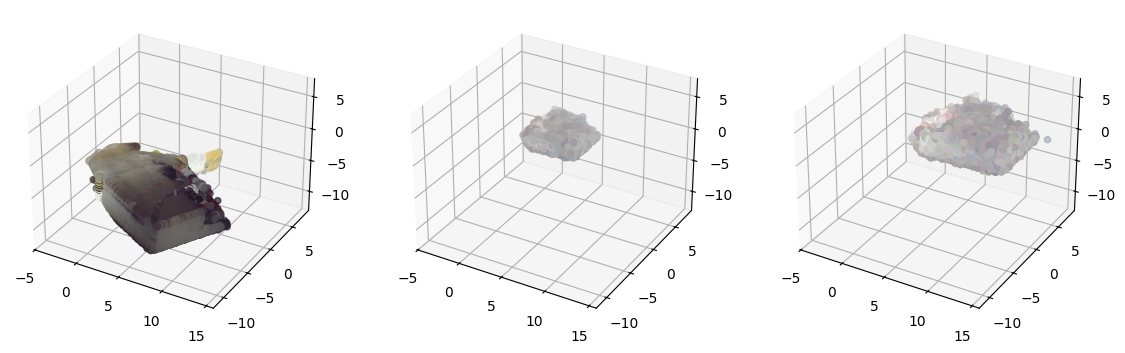

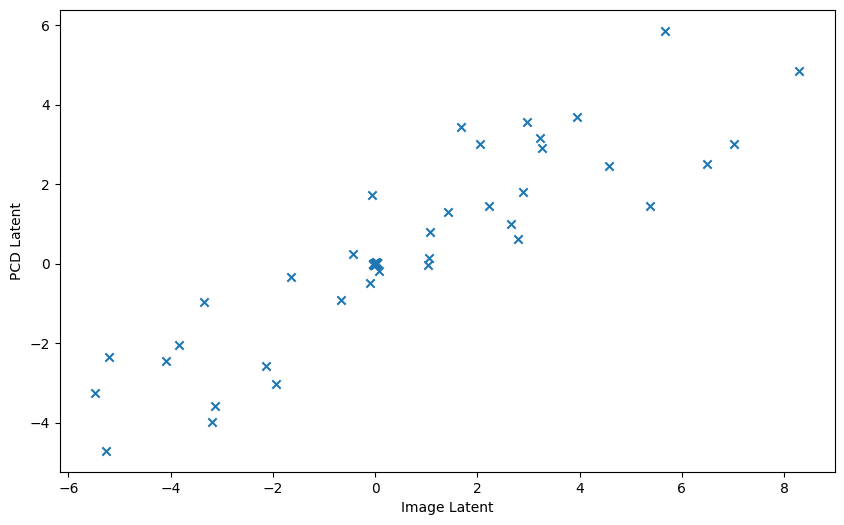

In [23]:
## Visualization
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1,3,figsize=(14,6))
ax[0].imshow(img_in)
ax[0].set_title('Original')
ax[1].imshow(img_img)
ax[1].set_title('Image -> Image')
ax[2].imshow(pcd_img)
ax[2].set_title('PCD -> Image')
fig.show()

fig = plt.figure(figsize=(14, 6))
ax0 = fig.add_subplot(1, 3, 1, projection="3d")
ax1 = fig.add_subplot(1, 3, 2, projection="3d")
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
ax0.scatter(-pcd_in[:,0],-pcd_in[:,1],pcd_in[:,2],c=pcd_in[:,3:])
ax1.scatter(-pcd_pcd[:,0],-pcd_pcd[:,1],pcd_pcd[:,2],c=pcd_pcd[:,3:])
ax2.scatter(-img_pcd[:,0],-img_pcd[:,1],img_pcd[:,2],c=img_pcd[:,3:])

def set_axes_equal_3d(ax, x, y, z):
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    xmid, ymid, zmid = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
    r = 0.5 * max(x.max()-x.min(), y.max()-y.min(), z.max()-z.min())
    ax.set_xlim(xmid - r, xmid + r)
    ax.set_ylim(ymid - r, ymid + r)
    ax.set_zlim(zmid - r, zmid + r)
all_xyz = np.vstack([pcd_in[:, :3], pcd_pcd[:, :3], img_pcd[:, :3]])
X, Y, Z = all_xyz[:,0], all_xyz[:,1], all_xyz[:,2]

for ax in (ax0, ax1, ax2):
    set_axes_equal_3d(ax, -X, -Y, Z)
    #ax.view_init(elev=15, azim=45)

fig.show()

plt.figure(figsize=(10,6))
plt.xlabel('Image Latent')
plt.ylabel('PCD Latent')
plt.scatter(pred['z_img'],pred['z_pcd'],marker='x')

(-0.5, 511.5, 383.5, -0.5)

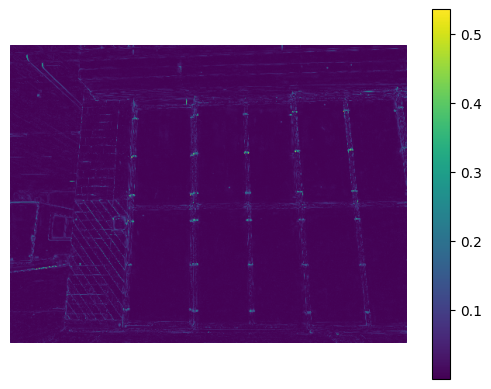

In [8]:
i = 0
d = (img_img.permute(2,0,1) - img_in.permute(2,0,1)).abs().detach().cpu()     # [3,H,W]
dmap = d.mean(dim=0)                            # [H,W]
plt.imshow(dmap)                                # expect mostly dark if L1=0.005 is real
plt.colorbar()
plt.axis("off")


In [ ]:
# graph laplacian
import torch_geometric.transforms as T
from torch_geometric.data import Data

pcd_in_data = Data()
pcd_in_data.x = batch['pcd']
pcd_in_data.edge_index = batch['edge_index']
pcd_in_data.edge_weights = batch['edge_weights']
#pe = T.AddLaplacianEigenvectorPE(12,'laplacian',is_undirected=True)
pe = T.AddRandomWalkPE(4,'laplacian')
pcd_in_data = pe(pcd_in_data)
lap_enc = pcd_in_data.laplacian

pred['pcd_pcd'] = pe(pred['pcd_pcd'])
lap_enc_pcd_pcd = pred['pcd_pcd'].laplacian

pred['img_pcd'] = pe(pred['img_pcd'])
lap_enc_img_pcd = pred['img_pcd'].laplacian

for e in range(12):
    fig = plt.figure(figsize=(14, 6))
    ax0 = fig.add_subplot(1, 3, 1, projection="3d")
    ax1 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2 = fig.add_subplot(1, 3, 3, projection="3d")
    ax0.scatter(pcd_in[:,0],pcd_in[:,1],-pcd_in[:,2],c=lap_enc[:,e])
    ax1.scatter(pcd_pcd[:,0],pcd_pcd[:,1],-pcd_pcd[:,2],c=lap_enc_pcd_pcd[:,e])
    ax2.scatter(img_pcd[:,0],img_pcd[:,1],-img_pcd[:,2],c=lap_enc_img_pcd[:,e])
    fig.show()
    #break

/cluster/home/btuncay/gnn_312/lib/python3.12/site-packages/torch_geometric/utils/sparse.py:276: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  adj = torch.sparse_csr_tensor(
